In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Week 1: Exploratory Data Analysis (EDA)

## Dataset
Online Retail II Dataset

## Objective
The objective of this project is to perform Exploratory Data Analysis (EDA) on the Online Retail II dataset to understand customer purchase behavior, identify data quality issues, analyze top-selling products, evaluate country-wise sales performance, and study monthly revenue trends.

## 1. Load the Dataset

In [ ]:
df = pd.read_csv("online_retail_II.csv", encoding="latin1")

df.head()

## 2. Basic Information

In [ ]:
print("Shape of Dataset:")
print(df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

Shape of Dataset:
(1067371, 8)

Column Names:
Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='str')

Data Types:
Invoice            str
StockCode          str
Description        str
Quantity         int64
InvoiceDate        str
Price          float64
Customer ID    float64
Country            str
dtype: object


In [ ]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  str    
 1   StockCode    1067371 non-null  str    
 2   Description  1062989 non-null  str    
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  str    
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  str    
dtypes: float64(2), int64(1), str(5)
memory usage: 136.6 MB


### Observation

- The dataset contains **1,067,371 rows** and **8 columns**.
- It includes product details, invoice information, customer IDs, prices, quantities, and countries.
- Both numerical and categorical variables are present.

## 3. Missing Values and Duplicate Rows

In [ ]:
df.isnull().sum()

Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64

### Observation

The dataset contains missing values in the **Description** and **Customer ID** columns. Other columns have no missing values.

In [ ]:
df.duplicated().sum()

np.int64(34335)

### Observation

The dataset contains duplicate records. These duplicates are identified but are not removed because this assignment focuses on exploratory data analysis.

## 4. Top 10 Best-Selling Products by Quantity

In [ ]:
top_quantity = (
    df.groupby("Description")["Quantity"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_quantity

Description
WORLD WAR 2 GLIDERS ASSTD DESIGNS     108545
WHITE HANGING HEART T-LIGHT HOLDER     93050
ASSORTED COLOUR BIRD ORNAMENT          81306
JUMBO BAG RED RETROSPOT                78090
BROCADE RING PURSE                     70700
PACK OF 60 PINK PAISLEY CAKE CASES     56575
60 TEATIME FAIRY CAKE CASES            54366
SMALL POPCORN HOLDER                   49616
PACK OF 72 RETROSPOT CAKE CASES        49344
PACK OF 72 RETRO SPOT CAKE CASES       46106
Name: Quantity, dtype: int64

### Graph Observation

The bar chart clearly shows that **WORLD WAR 2 GLIDERS ASSTD DESIGNS** is the best-selling product based on quantity sold.

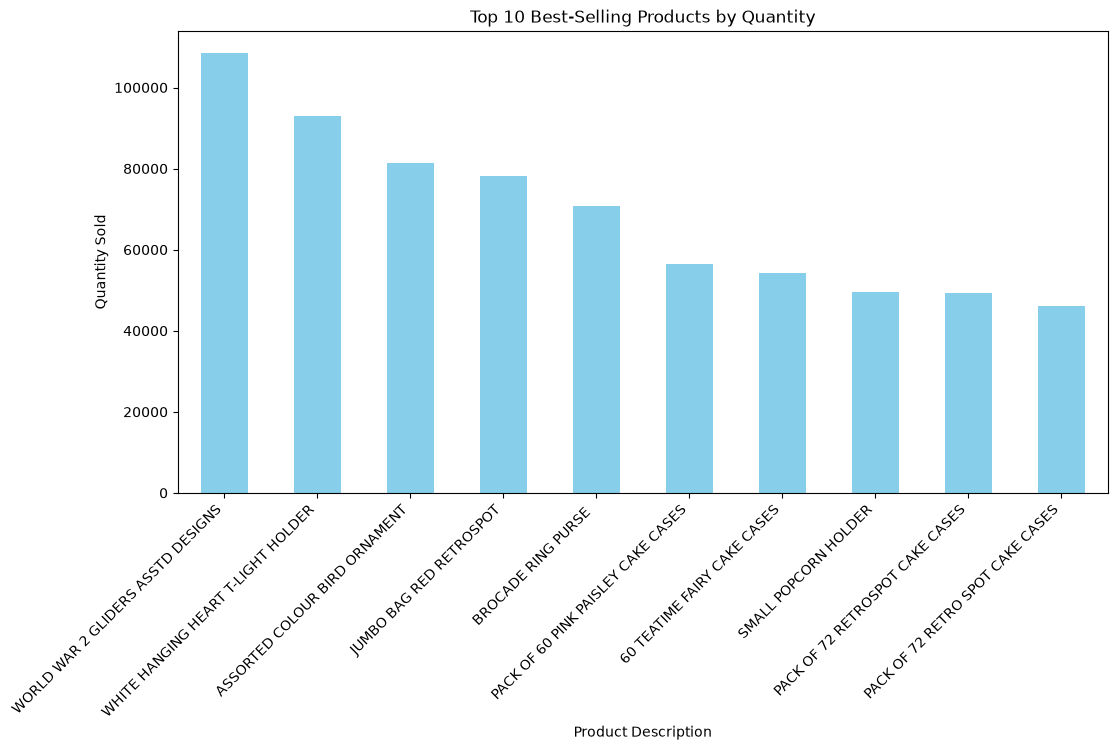

In [ ]:
plt.figure(figsize=(12,6))

top_quantity.plot(kind="bar", color="skyblue")

plt.title("Top 10 Best-Selling Products by Quantity")
plt.xlabel("Product Description")
plt.ylabel("Quantity Sold")

plt.xticks(rotation=45, ha="right")

plt.show()

## 5. Top 10 Products by Revenue

In [ ]:
df["Revenue"] = df["Quantity"] * df["Price"]

df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


### Explanation

A new column named **Revenue** is created by multiplying the **Quantity** sold by the **Price** of each product. This allows us to calculate the total revenue generated by each transaction.

In [ ]:
top_revenue = (
    df.groupby("Description")["Revenue"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_revenue

Description
REGENCY CAKESTAND 3 TIER               327813.65
DOTCOM POSTAGE                         322647.47
WHITE HANGING HEART T-LIGHT HOLDER     257533.90
JUMBO BAG RED RETROSPOT                148800.64
PARTY BUNTING                          147948.50
ASSORTED COLOUR BIRD ORNAMENT          131413.85
PAPER CHAIN KIT 50'S CHRISTMAS         121662.14
POSTAGE                                112341.00
CHILLI LIGHTS                           84854.16
ROTATING SILVER ANGELS T-LIGHT HLDR     73814.72
Name: Revenue, dtype: float64

### Observation

The table above shows the **top 10 products** that generated the highest revenue. The product **REGENCY CAKESTAND 3 TIER** generated the highest revenue, followed by **DOTCOM POSTAGE** and **WHITE HANGING HEART T-LIGHT HOLDER**.

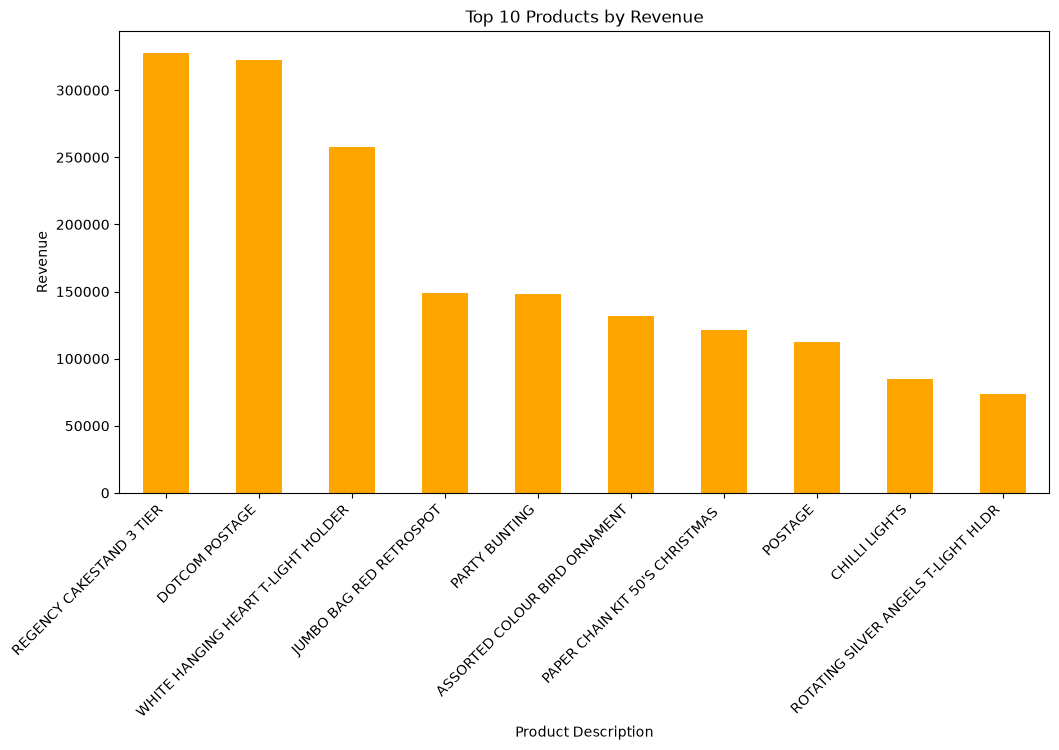

In [ ]:
plt.figure(figsize=(12,6))

top_revenue.plot(kind="bar", color="orange")

plt.title("Top 10 Products by Revenue")
plt.xlabel("Product Description")
plt.ylabel("Revenue")

plt.xticks(rotation=45, ha="right")

plt.show()


### Graph Observation

The bar chart provides a visual comparison of the top revenue-generating products. It clearly shows that **REGENCY CAKESTAND 3 TIER** is the highest revenue-generating product, while the remaining products also contribute significantly to the company's overall sales.

## 6. Sales Performance by Country

In [ ]:
country_sales = (
    df.groupby("Country")["Revenue"]
      .sum()
      .sort_values(ascending=False)
)

country_sales.head(10)

Country
United Kingdom    1.638258e+07
EIRE              6.155196e+05
Netherlands       5.485249e+05
Germany           4.179886e+05
France            3.281918e+05
Australia         1.671291e+05
Switzerland       9.972876e+04
Spain             9.185948e+04
Sweden            8.780942e+04
Denmark           6.574109e+04
Name: Revenue, dtype: float64

### Observation

The table above shows the top 10 countries based on total revenue. The **United Kingdom** generated the highest revenue, followed by **EIRE** and the **Netherlands**.

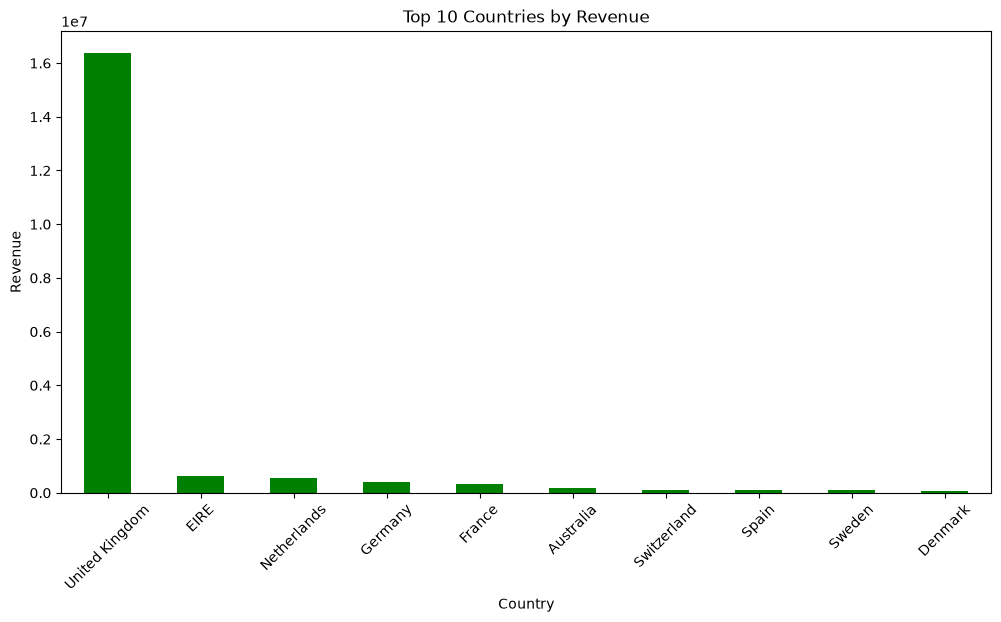

In [ ]:
plt.figure(figsize=(12,6))

country_sales.head(10).plot(kind="bar", color="green")

plt.title("Top 10 Countries by Revenue")
plt.xlabel("Country")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.show()

### Graph Observation

The bar chart clearly shows that the **United Kingdom** is the company's largest market, contributing significantly more revenue than any other country.

## 7. Monthly Sales Trend

In [ ]:
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

df["InvoiceDate"].head()

0   2009-12-01 07:45:00
1   2009-12-01 07:45:00
2   2009-12-01 07:45:00
3   2009-12-01 07:45:00
4   2009-12-01 07:45:00
Name: InvoiceDate, dtype: datetime64[us]

### Explanation

The **InvoiceDate** column is converted from text format into a datetime format so that monthly sales trends can be analyzed.

In [ ]:
df["Month"] = df["InvoiceDate"].dt.to_period("M")

df[["InvoiceDate", "Month"]].head()

,InvoiceDate,Month
0,2009-12-01 07:45:00,2009-12
1,2009-12-01 07:45:00,2009-12
2,2009-12-01 07:45:00,2009-12
3,2009-12-01 07:45:00,2009-12
4,2009-12-01 07:45:00,2009-12


### Explanation

A new column named **Month** is created by extracting the year and month from the InvoiceDate column.

In [ ]:
monthly_sales = (
    df.groupby("Month")["Revenue"]
      .sum()
)

monthly_sales

Month
2009-12     799847.110
2010-01     624032.892
2010-02     533091.426
2010-03     765848.761
2010-04     590580.432
2010-05     615322.830
2010-06     679786.610
2010-07     575236.360
2010-08     656776.340
2010-09     853650.431
2010-10    1045168.350
2010-11    1422654.642
2010-12    1126445.470
2011-01     560000.260
2011-02     498062.650
2011-03     683267.080
2011-04     493207.121
2011-05     723333.510
2011-06     691123.120
2011-07     681300.111
2011-08     682680.510
2011-09    1019687.622
2011-10    1070704.670
2011-11    1461756.250
2011-12     433686.010
Freq: M, Name: Revenue, dtype: float64

### Observation

The table above shows the total revenue generated in each month throughout the dataset.

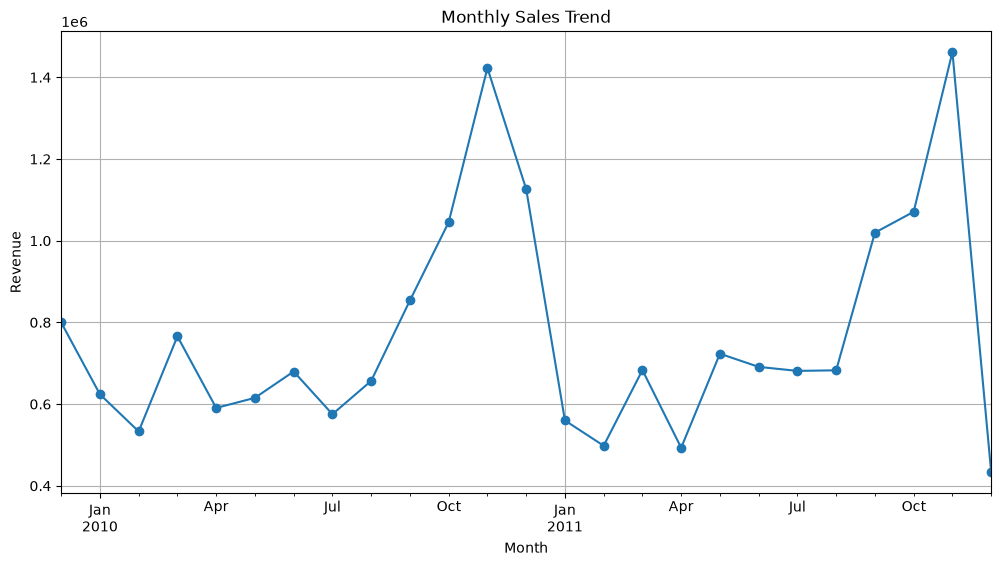

In [ ]:
plt.figure(figsize=(12,6))

monthly_sales.plot(marker="o")

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.grid(True)

plt.show()

### Graph Observation

The line chart shows that sales generally increase toward the end of each year. **November** records the highest revenue, indicating strong seasonal demand before the holiday season.

## 8. Correlation Heatmap

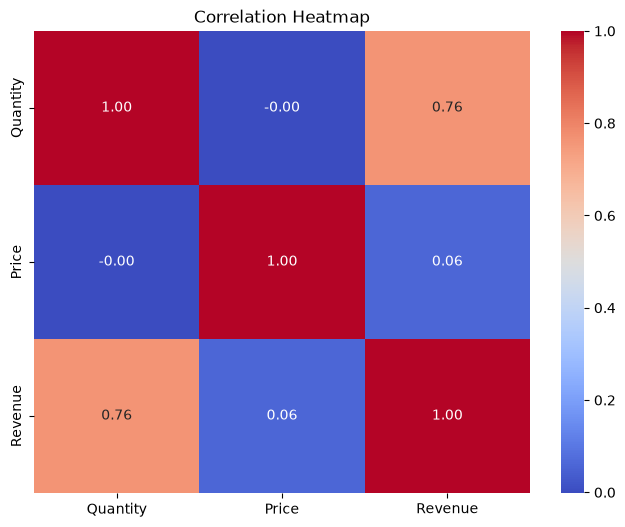

In [ ]:
plt.figure(figsize=(8,6))

correlation = df[["Quantity", "Price", "Revenue"]].corr()

sns.heatmap(correlation,
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Correlation Heatmap")

plt.show()

### Observation

The heatmap shows that **Quantity** has a strong positive correlation with **Revenue (0.76)**, while **Price** has only a weak correlation with Revenue. This indicates that sales volume contributes more to revenue than product price.

## 9. Outlier Detection

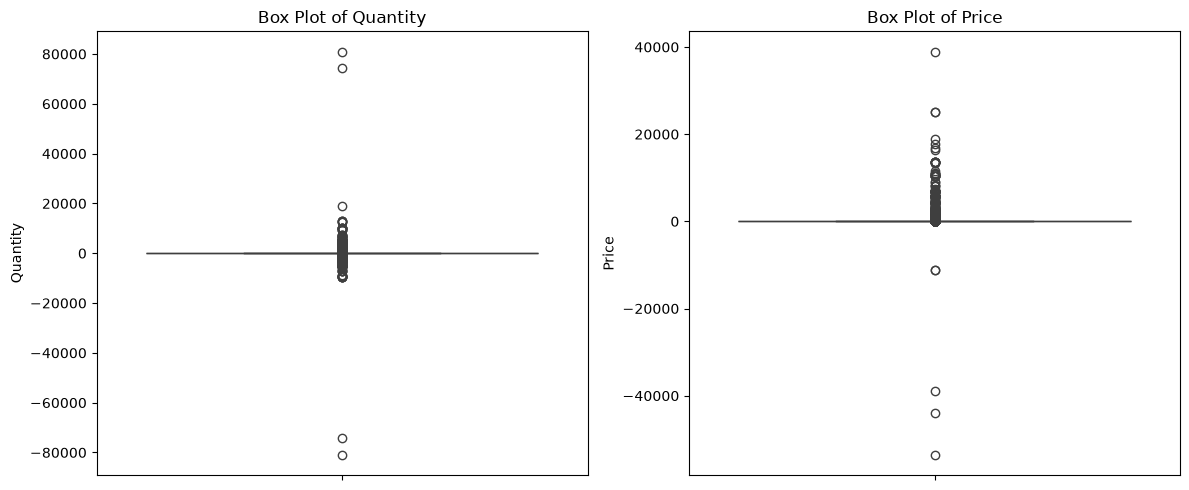

In [ ]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.boxplot(y=df["Quantity"])
plt.title("Box Plot of Quantity")

plt.subplot(1,2,2)
sns.boxplot(y=df["Price"])
plt.title("Box Plot of Price")

plt.tight_layout()

plt.show()

### Observation

The box plots reveal several outliers in both **Quantity** and **Price**. Negative values likely represent returned or cancelled orders, while extremely high values indicate bulk purchases or exceptional transactions.


## 10. Business Insights

### Key Findings

1. The **United Kingdom** is the largest revenue-generating market.

2. A small number of products contribute significantly to total sales and revenue.

3. Sales increase toward the end of the year, with **November** showing the highest revenue.

4. The correlation analysis indicates that **Quantity** has a stronger impact on revenue than **Price**.

5. The dataset contains missing values, duplicate records, and outliers, which should be considered during future data-cleaning and preprocessing.